# Notebook 3 — Controlled Anomaly Injection and Baseline Benchmark

This notebook:
- loads the processed claim-level analytical and model-feature tables from Notebook 2
- creates clean train / validation / test splits
- fits train-only preprocessing and rarity features
- injects controlled anomalies into validation and test sets
- benchmarks three classical unsupervised models:
  - Isolation Forest
  - Local Outlier Factor
  - One-Class SVM
- evaluates performance across 1%, 3%, and 5% anomaly-rate assumptions
- saves score files, metric tables, split files, and figures for later notebooks

## Design notes
- Training is performed on the clean training split only.
- Injection is applied to validation and test only.
- Contamination / anomaly-rate settings are treated as **benchmark assumptions**, not real-world prevalence estimates.
- A capped benchmark training subset is used for model fitting to keep runtime feasible in Colab, especially for OC-SVM.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Cell 1 - Load data and Libraries
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.metrics import average_precision_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import RobustScaler
from sklearn.svm import OneClassSVM

THESIS_ROOT = Path('/content/drive/MyDrive/NyanThesisAnomaly')

with open(THESIS_ROOT / 'project_paths.json', 'r', encoding='utf-8') as f:
    PROJECT_PATHS = json.load(f)

DATA_PROCESSED_DIR = Path(PROJECT_PATHS['DATA_PROCESSED_DIR'])
OUTPUTS_DIR = Path(PROJECT_PATHS['OUTPUTS_DIR'])
TABLES_DIR = Path(PROJECT_PATHS['TABLES_DIR'])
FIGURES_DIR = Path(PROJECT_PATHS['FIGURES_DIR'])
FILES_DIR = Path(PROJECT_PATHS['FILES_DIR'])
NOTEBOOK_EXPORTS_DIR = Path(PROJECT_PATHS['NOTEBOOK_EXPORTS_DIR'])
PHASE1_DIR = Path(PROJECT_PATHS['PHASE1_DIR'])

ANALYTICAL_PATH = DATA_PROCESSED_DIR / 'claims_analytical_table_v1.parquet'
MODEL_FEATURES_PATH = DATA_PROCESSED_DIR / 'claims_model_features_v1.parquet'

print('Analytical path:', ANALYTICAL_PATH)
print('Model features path:', MODEL_FEATURES_PATH)
print('Phase 1 output dir:', PHASE1_DIR)

Analytical path: /content/drive/MyDrive/NyanThesisAnomaly/data/processed/claims_analytical_table_v1.parquet
Model features path: /content/drive/MyDrive/NyanThesisAnomaly/data/processed/claims_model_features_v1.parquet
Phase 1 output dir: /content/drive/MyDrive/NyanThesisAnomaly/outputs/phase1_benchmark


In [ ]:
#Cell 2 - Load processed data from Notebook 2
claims_analytical = pd.read_parquet(ANALYTICAL_PATH)
model_features = pd.read_parquet(MODEL_FEATURES_PATH)

print('Analytical shape:', claims_analytical.shape)
print('Model feature shape:', model_features.shape)

display(claims_analytical.head())
display(model_features.head())


Analytical shape: (175005, 103)
Model feature shape: (175005, 23)


,CLAIM_KEY,DESYNPUF_ID,CLM_ID,SEGMENT,PRVDR_NUM,AT_PHYSN_NPI,OP_PHYSN_NPI,OT_PHYSN_NPI,CLM_FROM_DT,CLM_THRU_DT,...,HCPCS_CD_36,HCPCS_CD_37,HCPCS_CD_38,HCPCS_CD_39,HCPCS_CD_40,HCPCS_CD_41,HCPCS_CD_42,HCPCS_CD_43,HCPCS_CD_44,HCPCS_CD_45
0,542372281246633_1,00024B3D2352D2D0,542372281246633,1,5200YU,5972737463.0,<NA>,<NA>,2010-05-26,2010-05-26,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,542702280893497_1,0002F28CE057345B,542702280893497,1,3900RQ,3981876528.0,<NA>,<NA>,2010-04-28,2010-04-28,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,542712281107503_1,000345A39D4157C9,542712281107503,1,2300CS,2146329983.0,<NA>,2146329983.0,2010-08-01,2010-08-01,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,542912281339207_1,000489E7EAAD463F,542912281339207,1,1513WQ,2462820318.0,2462820318.0,<NA>,2010-12-12,2010-12-12,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,542862281135179_1,0007F12A492FD25D,542862281135179,1,4200BS,4341915698.0,<NA>,<NA>,2010-01-24,2010-01-24,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


,CLAIM_KEY,CLM_PMT_AMT,NCH_PRMRY_PYR_CLM_PD_AMT,total_beneficiary_liability,claim_duration_days,claim_from_month,claim_from_dayofweek,claim_from_day,is_weekend_claim,is_same_day_claim,...,has_admitting_diag,has_any_diag,has_any_proc,has_any_hcpcs,zero_payment_flag,log_clm_pmt_amt,log_primary_payer_amt,log_total_bene_liability,high_cost_flag_p95,extreme_cost_flag_p99
0,542372281246633_1,40.0,0.0,0.0,0,5,2,26,0,1,...,0,1,0,1,0,3.713572,0.0,0.000000,0,0
1,542702280893497_1,50.0,0.0,10.0,0,4,2,28,0,1,...,0,1,0,1,0,3.931826,0.0,2.397895,0,0
2,542712281107503_1,90.0,0.0,40.0,0,8,6,1,1,1,...,0,1,0,1,0,4.510860,0.0,3.713572,0,0
3,542912281339207_1,300.0,0.0,100.0,0,12,6,12,1,1,...,0,1,0,1,0,5.707110,0.0,4.615121,0,0
4,542862281135179_1,200.0,0.0,0.0,0,1,6,24,1,1,...,0,1,0,1,0,5.303305,0.0,0.000000,0,0


In [ ]:
#Cell 3 - Align analytical and model tables on CLAIM_KEY
merged = model_features.merge(
    claims_analytical[['CLAIM_KEY', 'primary_diag_code', 'primary_proc_code', 'primary_hcpcs_code']],
    on='CLAIM_KEY',
    how='left',
    validate='one_to_one'
)

print('Merged shape:', merged.shape)
print('Unique CLAIM_KEY count:', merged['CLAIM_KEY'].nunique())

display(merged[['CLAIM_KEY', 'primary_diag_code', 'primary_proc_code', 'primary_hcpcs_code']].head())


Merged shape: (175005, 26)
Unique CLAIM_KEY count: 175005


,CLAIM_KEY,primary_diag_code,primary_proc_code,primary_hcpcs_code
0,542372281246633_1,V821,<NA>,G0202
1,542702280893497_1,7210,<NA>,72052
2,542712281107503_1,V4366,<NA>,97110
3,542912281339207_1,9224,<NA>,<NA>
4,542862281135179_1,20302,<NA>,36415


In [ ]:
#Cell 4 - Create reproducible train / validation / test splits
RANDOM_STATE = 42

claim_keys = merged['CLAIM_KEY'].drop_duplicates().reset_index(drop=True)

train_keys, temp_keys = train_test_split(
    claim_keys,
    test_size=0.30,
    random_state=RANDOM_STATE,
    shuffle=True
)

val_keys, test_keys = train_test_split(
    temp_keys,
    test_size=0.50,
    random_state=RANDOM_STATE,
    shuffle=True
)

train_df = merged[merged['CLAIM_KEY'].isin(train_keys)].copy()
val_df = merged[merged['CLAIM_KEY'].isin(val_keys)].copy()
test_df = merged[merged['CLAIM_KEY'].isin(test_keys)].copy()

split_summary = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'n_rows': [len(train_df), len(val_df), len(test_df)],
    'pct_of_total': [
        round(len(train_df) / len(merged) * 100, 2),
        round(len(val_df) / len(merged) * 100, 2),
        round(len(test_df) / len(merged) * 100, 2),
    ]
})

display(split_summary)

split_summary_path = PHASE1_DIR / '03_split_summary.csv'
split_summary.to_csv(split_summary_path, index=False)

pd.DataFrame({'CLAIM_KEY': train_keys}).to_csv(PHASE1_DIR / '03_train_claim_keys.csv', index=False)
pd.DataFrame({'CLAIM_KEY': val_keys}).to_csv(PHASE1_DIR / '03_validation_claim_keys.csv', index=False)
pd.DataFrame({'CLAIM_KEY': test_keys}).to_csv(PHASE1_DIR / '03_test_claim_keys.csv', index=False)

print('Saved split files to:', PHASE1_DIR)


,split,n_rows,pct_of_total
0,train,122503,70.0
1,validation,26251,15.0
2,test,26251,15.0


Saved split files to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/phase1_benchmark


In [ ]:
#Cell 5 - Fit train-only rarity maps for code-anchor features
CODE_COLS = ['primary_diag_code', 'primary_proc_code', 'primary_hcpcs_code']

def build_frequency_map(series):
    clean = series.dropna().astype(str)
    if clean.empty:
        return {}
    freq = clean.value_counts(normalize=True)
    return freq.to_dict()

diag_freq_map = build_frequency_map(train_df['primary_diag_code'])
proc_freq_map = build_frequency_map(train_df['primary_proc_code'])
hcpcs_freq_map = build_frequency_map(train_df['primary_hcpcs_code'])

pair_series = (
    train_df['primary_diag_code'].astype('string').fillna('MISSING')
    + '||' +
    train_df['primary_hcpcs_code'].astype('string').fillna('MISSING')
)
pair_freq_map = pair_series.value_counts(normalize=True).to_dict()

def add_rarity_features(frame):
    out = frame.copy()

    out['primary_diag_freq_train'] = out['primary_diag_code'].astype('string').map(diag_freq_map).fillna(0.0)
    out['primary_proc_freq_train'] = out['primary_proc_code'].astype('string').map(proc_freq_map).fillna(0.0)
    out['primary_hcpcs_freq_train'] = out['primary_hcpcs_code'].astype('string').map(hcpcs_freq_map).fillna(0.0)

    pair_key = (
        out['primary_diag_code'].astype('string').fillna('MISSING')
        + '||' +
        out['primary_hcpcs_code'].astype('string').fillna('MISSING')
    )
    out['diag_hcpcs_pair_freq_train'] = pair_key.map(pair_freq_map).fillna(0.0)

    out['rare_primary_diag_flag'] = (out['primary_diag_freq_train'] <= 0.001).astype('int8')
    out['rare_primary_proc_flag'] = (out['primary_proc_freq_train'] <= 0.001).astype('int8')
    out['rare_primary_hcpcs_flag'] = (out['primary_hcpcs_freq_train'] <= 0.001).astype('int8')
    out['rare_diag_hcpcs_pair_flag'] = (out['diag_hcpcs_pair_freq_train'] <= 0.0005).astype('int8')

    return out

train_df = add_rarity_features(train_df)
val_df = add_rarity_features(val_df)
test_df = add_rarity_features(test_df)

display(train_df[[
    'primary_diag_freq_train',
    'primary_proc_freq_train',
    'primary_hcpcs_freq_train',
    'diag_hcpcs_pair_freq_train',
    'rare_primary_diag_flag',
    'rare_primary_proc_flag',
    'rare_primary_hcpcs_flag',
    'rare_diag_hcpcs_pair_flag'
]].head())


,primary_diag_freq_train,primary_proc_freq_train,primary_hcpcs_freq_train,diag_hcpcs_pair_freq_train,rare_primary_diag_flag,rare_primary_proc_flag,rare_primary_hcpcs_flag,rare_diag_hcpcs_pair_flag
1,0.000498,0.0,0.000259,0.000008,1,1,1,1
2,0.000098,0.0,0.029033,0.000008,1,1,0,1
3,0.000090,0.0,0.000000,0.000033,1,1,1,1
5,0.000033,0.0,0.004035,0.000008,1,1,0,1
6,0.000073,0.0,0.036885,0.000008,1,1,0,1


In [ ]:
#Cell 6 - Add cyclical temporal encodings and define final baseline feature columns
def add_cyclical_time_features(frame):
    out = frame.copy()

    out['claim_from_month_sin'] = np.sin(2 * np.pi * out['claim_from_month'].fillna(0) / 12)
    out['claim_from_month_cos'] = np.cos(2 * np.pi * out['claim_from_month'].fillna(0) / 12)

    out['claim_from_dayofweek_sin'] = np.sin(2 * np.pi * out['claim_from_dayofweek'].fillna(0) / 7)
    out['claim_from_dayofweek_cos'] = np.cos(2 * np.pi * out['claim_from_dayofweek'].fillna(0) / 7)

    return out

train_df = add_cyclical_time_features(train_df)
val_df = add_cyclical_time_features(val_df)
test_df = add_cyclical_time_features(test_df)

FINAL_FEATURE_COLS = [
    'CLM_PMT_AMT',
    'NCH_PRMRY_PYR_CLM_PD_AMT',
    'total_beneficiary_liability',
    'claim_duration_days',
    'claim_from_month',
    'claim_from_dayofweek',
    'claim_from_day',
    'is_weekend_claim',
    'is_same_day_claim',
    'diag_code_count',
    'proc_code_count',
    'hcpcs_code_count',
    'has_admitting_diag',
    'has_any_diag',
    'has_any_proc',
    'has_any_hcpcs',
    'zero_payment_flag',
    'log_clm_pmt_amt',
    'log_primary_payer_amt',
    'log_total_bene_liability',
    'high_cost_flag_p95',
    'extreme_cost_flag_p99',
    'primary_diag_freq_train',
    'primary_proc_freq_train',
    'primary_hcpcs_freq_train',
    'diag_hcpcs_pair_freq_train',
    'rare_primary_diag_flag',
    'rare_primary_proc_flag',
    'rare_primary_hcpcs_flag',
    'rare_diag_hcpcs_pair_flag',
    'claim_from_month_sin',
    'claim_from_month_cos',
    'claim_from_dayofweek_sin',
    'claim_from_dayofweek_cos',
]

print('Final feature count:', len(FINAL_FEATURE_COLS))
print(FINAL_FEATURE_COLS)


Final feature count: 34
['CLM_PMT_AMT', 'NCH_PRMRY_PYR_CLM_PD_AMT', 'total_beneficiary_liability', 'claim_duration_days', 'claim_from_month', 'claim_from_dayofweek', 'claim_from_day', 'is_weekend_claim', 'is_same_day_claim', 'diag_code_count', 'proc_code_count', 'hcpcs_code_count', 'has_admitting_diag', 'has_any_diag', 'has_any_proc', 'has_any_hcpcs', 'zero_payment_flag', 'log_clm_pmt_amt', 'log_primary_payer_amt', 'log_total_bene_liability', 'high_cost_flag_p95', 'extreme_cost_flag_p99', 'primary_diag_freq_train', 'primary_proc_freq_train', 'primary_hcpcs_freq_train', 'diag_hcpcs_pair_freq_train', 'rare_primary_diag_flag', 'rare_primary_proc_flag', 'rare_primary_hcpcs_flag', 'rare_diag_hcpcs_pair_flag', 'claim_from_month_sin', 'claim_from_month_cos', 'claim_from_dayofweek_sin', 'claim_from_dayofweek_cos']


In [ ]:
#Cell 7 - Fit train-only imputation values and robust scaling
train_medians = train_df[FINAL_FEATURE_COLS].median(numeric_only=True)

def prepare_numeric_features(frame, scaler=None, fit_scaler=False):
    X = frame[FINAL_FEATURE_COLS].copy()
    X = X.fillna(train_medians)

    if fit_scaler:
        scaler = RobustScaler()
        X_scaled = scaler.fit_transform(X)
    else:
        X_scaled = scaler.transform(X)

    X_scaled = pd.DataFrame(X_scaled, columns=FINAL_FEATURE_COLS, index=frame.index)
    return X, X_scaled, scaler

X_train_raw, X_train_scaled, scaler = prepare_numeric_features(train_df, fit_scaler=True)
X_val_raw, X_val_scaled, _ = prepare_numeric_features(val_df, scaler=scaler, fit_scaler=False)
X_test_raw, X_test_scaled, _ = prepare_numeric_features(test_df, scaler=scaler, fit_scaler=False)

print('Train scaled shape:', X_train_scaled.shape)
display(X_train_scaled.head())

preprocess_meta = {
    'n_final_features': len(FINAL_FEATURE_COLS),
    'feature_columns': FINAL_FEATURE_COLS,
    'train_rows': int(len(train_df)),
    'validation_rows': int(len(val_df)),
    'test_rows': int(len(test_df)),
}


Train scaled shape: (122503, 34)


,CLM_PMT_AMT,NCH_PRMRY_PYR_CLM_PD_AMT,total_beneficiary_liability,claim_duration_days,claim_from_month,claim_from_dayofweek,claim_from_day,is_weekend_claim,is_same_day_claim,diag_code_count,...,primary_hcpcs_freq_train,diag_hcpcs_pair_freq_train,rare_primary_diag_flag,rare_primary_proc_flag,rare_primary_hcpcs_flag,rare_diag_hcpcs_pair_flag,claim_from_month_sin,claim_from_month_cos,claim_from_dayofweek_sin,claim_from_dayofweek_cos
1,-0.1875,0.0,-0.125,0.0,-0.2,-0.25,0.866667,0.0,0.0,0.000000,...,-0.203334,-0.136364,0.0,0.0,1.0,0.0,0.267949,-3.660254e-01,0.62349,0.000000
2,0.0625,0.0,0.250,0.0,0.6,0.75,-0.933333,1.0,0.0,1.666667,...,0.585952,-0.136364,0.0,0.0,0.0,0.0,-1.000000,-3.660254e-01,-0.50000,0.554958
3,1.3750,0.0,1.000,0.0,1.4,0.75,-0.200000,1.0,0.0,1.666667,...,-0.210440,0.000000,0.0,0.0,1.0,0.0,-0.366025,7.320508e-01,-0.50000,0.554958
5,0.1250,0.0,1.000,0.0,-0.6,-0.25,0.600000,0.0,0.0,0.000000,...,-0.099754,-0.136364,0.0,0.0,0.0,0.0,0.267949,3.660254e-01,0.62349,0.000000
6,20.1250,0.0,2.250,0.0,-0.4,-0.50,0.066667,0.0,0.0,-0.333333,...,0.801312,-0.136364,0.0,0.0,0.0,0.0,0.366025,1.793007e-16,0.50000,0.554958


In [ ]:
#Cell 8 - Create a capped benchmark training subset for fair and feasible model fitting
MAX_TRAIN_BENCHMARK = 30000

if len(X_train_scaled) > MAX_TRAIN_BENCHMARK:
    benchmark_idx = train_df.sample(n=MAX_TRAIN_BENCHMARK, random_state=RANDOM_STATE).index
else:
    benchmark_idx = train_df.index

train_benchmark_df = train_df.loc[benchmark_idx].copy()
X_train_benchmark = X_train_scaled.loc[benchmark_idx].copy()

benchmark_train_summary = pd.DataFrame({
    'metric': ['full_train_rows', 'benchmark_train_rows'],
    'value': [len(train_df), len(train_benchmark_df)]
})

display(benchmark_train_summary)

benchmark_train_summary.to_csv(PHASE1_DIR / '03_benchmark_train_summary.csv', index=False)


,metric,value
0,full_train_rows,122503
1,benchmark_train_rows,30000


In [ ]:
#Cell 9 - Define controlled anomaly injection functions
def choose_with_replacement(base_df, n, seed):
    rng = np.random.default_rng(seed)
    idx = rng.choice(base_df.index.to_numpy(), size=n, replace=True)
    return base_df.loc[idx].copy().reset_index(drop=True)

def inject_monetary_anomalies(base_df, n, seed):
    rng = np.random.default_rng(seed)
    sample = choose_with_replacement(base_df, n, seed)
    multiplier = rng.uniform(2.0, 5.0, size=n)

    sample['CLM_PMT_AMT'] = sample['CLM_PMT_AMT'].fillna(0) * multiplier
    sample['NCH_PRMRY_PYR_CLM_PD_AMT'] = sample['NCH_PRMRY_PYR_CLM_PD_AMT'].fillna(0) * rng.uniform(1.5, 4.0, size=n)
    sample['total_beneficiary_liability'] = sample['total_beneficiary_liability'].fillna(0) * rng.uniform(1.5, 4.0, size=n)

    sample['log_clm_pmt_amt'] = np.log1p(np.clip(sample['CLM_PMT_AMT'], 0, None))
    sample['log_primary_payer_amt'] = np.log1p(np.clip(sample['NCH_PRMRY_PYR_CLM_PD_AMT'], 0, None))
    sample['log_total_bene_liability'] = np.log1p(np.clip(sample['total_beneficiary_liability'], 0, None))

    sample['high_cost_flag_p95'] = 1
    sample['extreme_cost_flag_p99'] = 1

    return sample

def inject_temporal_anomalies(base_df, n, seed):
    rng = np.random.default_rng(seed)
    sample = choose_with_replacement(base_df, n, seed)

    max_duration = max(float(train_df['claim_duration_days'].quantile(0.99)), 7.0)

    sample['claim_duration_days'] = rng.integers(int(max_duration), int(max_duration * 2) + 1, size=n)
    sample['claim_from_dayofweek'] = rng.choice([5, 6], size=n)
    sample['is_weekend_claim'] = 1
    sample['is_same_day_claim'] = 0
    sample['claim_from_day'] = rng.integers(1, 29, size=n)

    sample['claim_from_dayofweek_sin'] = np.sin(2 * np.pi * sample['claim_from_dayofweek'] / 7)
    sample['claim_from_dayofweek_cos'] = np.cos(2 * np.pi * sample['claim_from_dayofweek'] / 7)

    return sample

def inject_coding_utilization_anomalies(base_df, n, seed):
    rng = np.random.default_rng(seed)
    sample = choose_with_replacement(base_df, n, seed)

    q_diag = max(int(train_df['diag_code_count'].quantile(0.99)), 5)
    q_proc = max(int(train_df['proc_code_count'].quantile(0.99)), 3)
    q_hcpcs = max(int(train_df['hcpcs_code_count'].quantile(0.99)), 8)

    sample['diag_code_count'] = rng.integers(max(3, q_diag - 2), q_diag + 3, size=n)
    sample['proc_code_count'] = rng.integers(max(2, q_proc - 1), q_proc + 2, size=n)
    sample['hcpcs_code_count'] = rng.integers(max(5, q_hcpcs - 3), q_hcpcs + 4, size=n)

    sample['has_any_diag'] = 1
    sample['has_any_proc'] = 1
    sample['has_any_hcpcs'] = 1
    sample['has_admitting_diag'] = 1

    sample['primary_diag_freq_train'] = 0.0
    sample['primary_proc_freq_train'] = 0.0
    sample['primary_hcpcs_freq_train'] = 0.0
    sample['diag_hcpcs_pair_freq_train'] = 0.0

    sample['rare_primary_diag_flag'] = 1
    sample['rare_primary_proc_flag'] = 1
    sample['rare_primary_hcpcs_flag'] = 1
    sample['rare_diag_hcpcs_pair_flag'] = 1

    return sample

def inject_mixed_anomalies(base_df, rate, seed):
    n_anomalies = max(1, int(round(len(base_df) * rate)))
    family_names = ['monetary', 'temporal', 'coding_utilization']
    family_sizes = [n_anomalies // 3, n_anomalies // 3, n_anomalies - 2 * (n_anomalies // 3)]

    injected_parts = []
    family_generators = {
        'monetary': inject_monetary_anomalies,
        'temporal': inject_temporal_anomalies,
        'coding_utilization': inject_coding_utilization_anomalies,
    }

    family_seed_offset = 0
    for family, size in zip(family_names, family_sizes):
        if size <= 0:
            continue
        part = family_generators[family](base_df, size, seed + family_seed_offset)
        part['is_injected_anomaly'] = 1
        part['injected_family'] = family
        part['source_claim_key'] = part['CLAIM_KEY']
        part['CLAIM_KEY'] = part['CLAIM_KEY'].astype(str) + f'_INJECTED_{family.upper()}_' + np.arange(len(part)).astype(str)
        injected_parts.append(part)
        family_seed_offset += 1000

    anomalies_df = pd.concat(injected_parts, ignore_index=True)
    normal_df = base_df.copy()
    normal_df['is_injected_anomaly'] = 0
    normal_df['injected_family'] = 'normal'
    normal_df['source_claim_key'] = normal_df['CLAIM_KEY']

    combined = pd.concat([normal_df, anomalies_df], ignore_index=True)
    return combined


In [ ]:
#Cell 10 - Smoke test the anomaly injection pipeline
validation_benchmark_example = inject_mixed_anomalies(val_df, rate=0.03, seed=RANDOM_STATE)

print('Validation example shape:', validation_benchmark_example.shape)
print('Injected anomaly count:', validation_benchmark_example['is_injected_anomaly'].sum())
display(validation_benchmark_example[['CLAIM_KEY', 'source_claim_key', 'is_injected_anomaly', 'injected_family']].head(10))
display(validation_benchmark_example['injected_family'].value_counts())


Validation example shape: (27039, 41)
Injected anomaly count: 788


,CLAIM_KEY,source_claim_key,is_injected_anomaly,injected_family
0,542372281246633_1,542372281246633_1,0,normal
1,542292280971106_1,542292280971106_1,0,normal
2,542722281352461_1,542722281352461_1,0,normal
3,542952281036148_1,542952281036148_1,0,normal
4,542332281430811_1,542332281430811_1,0,normal
5,542382281296138_1,542382281296138_1,0,normal
6,542392281641264_1,542392281641264_1,0,normal
7,542912281452348_1,542912281452348_1,0,normal
8,542252281137071_1,542252281137071_1,0,normal
9,542342280971645_1,542342280971645_1,0,normal


,count
injected_family,
normal,26251
coding_utilization,264
monetary,262
temporal,262


In [ ]:
#Cell 11 - Define model builders and anomaly-scoring helpers
def build_models(rate):
    models = {
        'iforest': IsolationForest(
            n_estimators=200,
            contamination=rate,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        'lof': LocalOutlierFactor(
            n_neighbors=35,
            contamination=rate,
            novelty=True
        ),
        'ocsvm': OneClassSVM(
            kernel='rbf',
            nu=rate,
            gamma='scale'
        ),
    }
    return models

def get_anomaly_scores(model, X, model_name):
    if hasattr(model, 'score_samples'):
        scores = -model.score_samples(X)
    else:
        scores = -model.decision_function(X)
    return np.asarray(scores)

def precision_at_k(y_true, scores, k):
    order = np.argsort(scores)[::-1]
    top_idx = order[:k]
    return float(np.mean(y_true[top_idx]))

def recall_at_k(y_true, scores, k):
    order = np.argsort(scores)[::-1]
    top_idx = order[:k]
    positives = np.sum(y_true)
    if positives == 0:
        return np.nan
    return float(np.sum(y_true[top_idx]) / positives)

def family_recall_at_k(eval_df, scores, k):
    anomaly_rows = eval_df[eval_df['is_injected_anomaly'] == 1].copy()
    if anomaly_rows.empty:
        return {}

    order = np.argsort(scores)[::-1]
    top_keys = set(eval_df.iloc[order[:k]]['CLAIM_KEY'].astype(str))

    recalls = {}
    for family in sorted(anomaly_rows['injected_family'].unique()):
        fam = anomaly_rows[anomaly_rows['injected_family'] == family]
        recalls[family] = float(np.mean(fam['CLAIM_KEY'].astype(str).isin(top_keys)))
    return recalls


In [ ]:
#Cell 12 - Run the baseline benchmark across 1%, 3%, and 5% settings
RATES = [0.01, 0.03, 0.05]

all_metrics = []
all_scores = []

for rate in RATES:
    print(f'Running benchmark for anomaly-rate assumption: {rate:.0%}')
    models = build_models(rate)

    for model_name, model in models.items():
        print(f'  Fitting {model_name}...')
        model.fit(X_train_benchmark)

        for split_name, base_df in [('validation', val_df), ('test', test_df)]:
            eval_df = inject_mixed_anomalies(base_df, rate=rate, seed=RANDOM_STATE + int(rate * 10000))
            X_eval_raw = eval_df[FINAL_FEATURE_COLS].copy().fillna(train_medians)
            X_eval_scaled = scaler.transform(X_eval_raw)

            scores = get_anomaly_scores(model, X_eval_scaled, model_name)
            y_true = eval_df['is_injected_anomaly'].to_numpy()
            k = int(np.sum(y_true))

            # Generate y_pred based on top k scores for confusion matrix
            order = np.argsort(scores)[::-1]
            y_pred = np.zeros_like(y_true, dtype=int)
            y_pred[order[:k]] = 1

            # Calculate confusion matrix components
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

            metric_row = {
                'split': split_name,
                'model': model_name,
                'assumed_rate': rate,
                'n_eval_rows': int(len(eval_df)),
                'n_injected_anomalies': int(k),
                'average_precision': float(average_precision_score(y_true, scores)),
                'roc_auc': float(roc_auc_score(y_true, scores)),
                'precision_at_k': precision_at_k(y_true, scores, k),
                'recall_at_k': recall_at_k(y_true, scores, k),
                'true_positives': int(tp),
                'false_positives': int(fp),
                'true_negatives': int(tn),
                'false_negatives': int(fn),
            }

            family_recalls = family_recall_at_k(eval_df, scores, k)
            for family_name, family_value in family_recalls.items():
                metric_row[f'recall_at_k__{family_name}'] = family_value

            all_metrics.append(metric_row)

            score_df = pd.DataFrame({
                'split': split_name,
                'model': model_name,
                'assumed_rate': rate,
                'CLAIM_KEY': eval_df['CLAIM_KEY'].astype(str),
                'source_claim_key': eval_df['source_claim_key'].astype(str),
                'is_injected_anomaly': y_true,
                'injected_family': eval_df['injected_family'].astype(str),
                'anomaly_score': scores,
            })
            all_scores.append(score_df)

metrics_df = pd.DataFrame(all_metrics)
scores_df = pd.concat(all_scores, ignore_index=True)

print('Metrics shape:', metrics_df.shape)
print('Scores shape:', scores_df.shape)

display(metrics_df.sort_values(['split', 'assumed_rate', 'average_precision'], ascending=[True, True, False]))

Running benchmark for anomaly-rate assumption: 1%
  Fitting iforest...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


  Fitting lof...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


  Fitting ocsvm...


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


  Fitting ocsvm...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OneClassSVM was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OneClassSVM was fitted with feature names
  warnings.warn(


Metrics shape: (18, 16)
Scores shape: (486702, 8)


,split,model,assumed_rate,n_eval_rows,n_injected_anomalies,average_precision,roc_auc,precision_at_k,recall_at_k,true_positives,false_positives,true_negatives,false_negatives,recall_at_k__coding_utilization,recall_at_k__monetary,recall_at_k__temporal
3,test,lof,0.01,26514,263,0.392233,0.935683,0.410646,0.410646,108,155,26096,155,0.348315,0.091954,0.793103
5,test,ocsvm,0.01,26514,263,0.087818,0.787597,0.250951,0.250951,66,197,26054,197,0.011236,0.057471,0.689655
1,test,iforest,0.01,26514,263,0.051525,0.903064,0.041825,0.041825,11,252,25999,252,0.056180,0.034483,0.034483
9,test,lof,0.03,27039,788,0.594239,0.944348,0.574873,0.574873,453,335,25916,335,0.640152,0.267176,0.816794
11,test,ocsvm,0.03,27039,788,0.195934,0.807170,0.317259,0.317259,250,538,25713,538,0.053030,0.122137,0.778626
7,test,iforest,0.03,27039,788,0.129339,0.897375,0.098985,0.098985,78,710,25541,710,0.094697,0.122137,0.080153
15,test,lof,0.05,27564,1313,0.669471,0.936121,0.642803,0.642803,844,469,25782,469,0.758542,0.343249,0.826087
17,test,ocsvm,0.05,27564,1313,0.221902,0.799844,0.339680,0.339680,446,867,25384,867,0.086560,0.121281,0.812357
13,test,iforest,0.05,27564,1313,0.194890,0.895384,0.176695,0.176695,232,1081,25170,1081,0.177677,0.219680,0.132723
2,validation,lof,0.01,26514,263,0.339973,0.947549,0.403042,0.403042,106,157,26094,157,0.348315,0.080460,0.781609


In [ ]:
#Cell 13 - Save benchmark metric and score outputs
metrics_csv_path = PHASE1_DIR / '03_baseline_benchmark_metrics.csv'
metrics_parquet_path = PHASE1_DIR / '03_baseline_benchmark_metrics.parquet'
scores_parquet_path = PHASE1_DIR / '03_baseline_benchmark_scores.parquet'

metrics_df.to_csv(metrics_csv_path, index=False)
metrics_df.to_parquet(metrics_parquet_path, index=False)
scores_df.to_parquet(scores_parquet_path, index=False)

print('Saved metrics CSV:', metrics_csv_path)
print('Saved metrics parquet:', metrics_parquet_path)
print('Saved scores parquet:', scores_parquet_path)

Saved metrics CSV: /content/drive/MyDrive/NyanThesisAnomaly/outputs/phase1_benchmark/03_baseline_benchmark_metrics.csv
Saved metrics parquet: /content/drive/MyDrive/NyanThesisAnomaly/outputs/phase1_benchmark/03_baseline_benchmark_metrics.parquet
Saved scores parquet: /content/drive/MyDrive/NyanThesisAnomaly/outputs/phase1_benchmark/03_baseline_benchmark_scores.parquet


In [ ]:
#Cell 14 - Create a compact benchmark summary table
summary_cols = [
    'split', 'model', 'assumed_rate',
    'average_precision', 'roc_auc', 'precision_at_k', 'recall_at_k',
    'true_positives', 'false_positives', 'true_negatives', 'false_negatives'
] + [c for c in metrics_df.columns if c.startswith('recall_at_k__')]

benchmark_summary = metrics_df[summary_cols].sort_values(['split', 'assumed_rate', 'average_precision'], ascending=[True, True, False]).reset_index(drop=True)

display(benchmark_summary)

benchmark_summary_path = TABLES_DIR / '03_baseline_benchmark_summary.csv'
benchmark_summary.to_csv(benchmark_summary_path, index=False)

print('Saved summary table to:', benchmark_summary_path)

,split,model,assumed_rate,average_precision,roc_auc,precision_at_k,recall_at_k,true_positives,false_positives,true_negatives,false_negatives,recall_at_k__coding_utilization,recall_at_k__monetary,recall_at_k__temporal
0,test,lof,0.01,0.392233,0.935683,0.410646,0.410646,108,155,26096,155,0.348315,0.091954,0.793103
1,test,ocsvm,0.01,0.087818,0.787597,0.250951,0.250951,66,197,26054,197,0.011236,0.057471,0.689655
2,test,iforest,0.01,0.051525,0.903064,0.041825,0.041825,11,252,25999,252,0.056180,0.034483,0.034483
3,test,lof,0.03,0.594239,0.944348,0.574873,0.574873,453,335,25916,335,0.640152,0.267176,0.816794
4,test,ocsvm,0.03,0.195934,0.807170,0.317259,0.317259,250,538,25713,538,0.053030,0.122137,0.778626
5,test,iforest,0.03,0.129339,0.897375,0.098985,0.098985,78,710,25541,710,0.094697,0.122137,0.080153
6,test,lof,0.05,0.669471,0.936121,0.642803,0.642803,844,469,25782,469,0.758542,0.343249,0.826087
7,test,ocsvm,0.05,0.221902,0.799844,0.339680,0.339680,446,867,25384,867,0.086560,0.121281,0.812357
8,test,iforest,0.05,0.194890,0.895384,0.176695,0.176695,232,1081,25170,1081,0.177677,0.219680,0.132723
9,validation,lof,0.01,0.339973,0.947549,0.403042,0.403042,106,157,26094,157,0.348315,0.080460,0.781609


Saved summary table to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/tables/03_baseline_benchmark_summary.csv


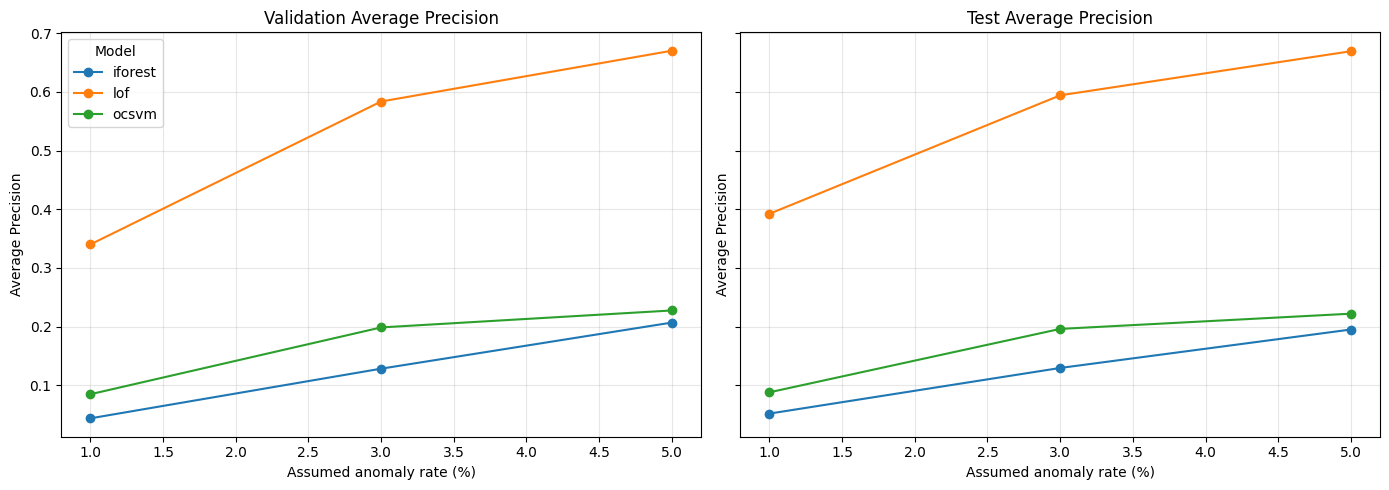

Saved figure to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/figures/03_average_precision_by_rate.png


In [ ]:
#Cell 15 - Plot benchmark performance by anomaly-rate assumption
plot_metric = 'average_precision'
plot_splits = ['validation', 'test']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, split_name in zip(axes, plot_splits):
    split_metrics = metrics_df[metrics_df['split'] == split_name].copy()
    for model_name in sorted(split_metrics['model'].unique()):
        temp = split_metrics[split_metrics['model'] == model_name].sort_values('assumed_rate')
        ax.plot(temp['assumed_rate'] * 100, temp[plot_metric], marker='o', label=model_name)

    ax.set_title(f'{split_name.title()} {plot_metric.replace("_", " ").title()}')
    ax.set_xlabel('Assumed anomaly rate (%)')
    ax.set_ylabel(plot_metric.replace('_', ' ').title())
    ax.grid(True, alpha=0.3)

axes[0].legend(title='Model')
plt.tight_layout()

fig1_path = FIGURES_DIR / '03_average_precision_by_rate.png'
plt.savefig(fig1_path, dpi=200, bbox_inches='tight')
plt.show()

print('Saved figure to:', fig1_path)

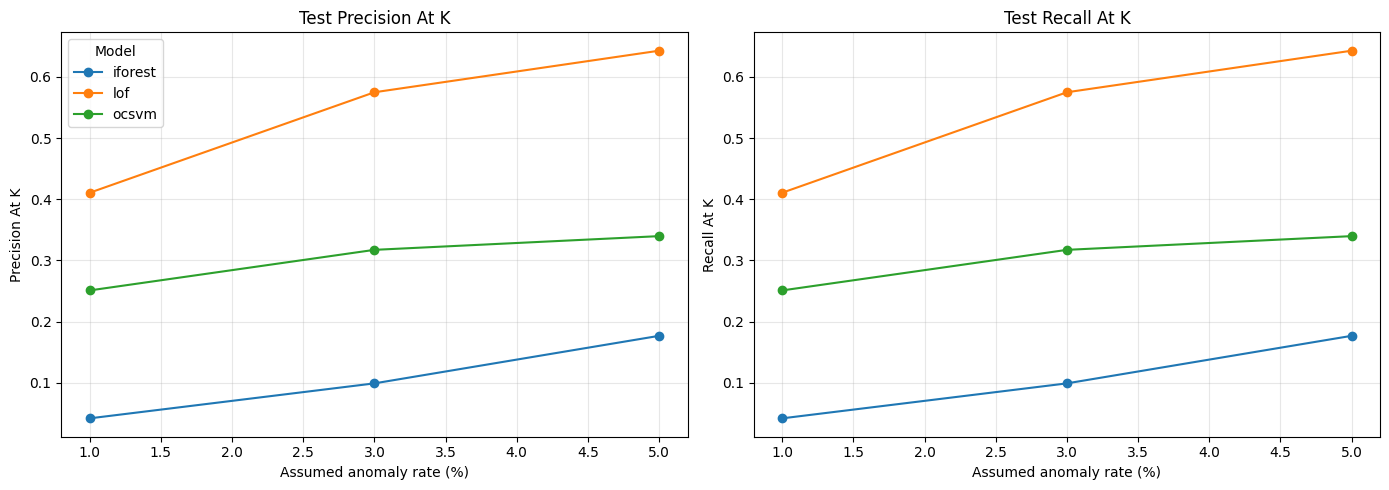

Saved figure to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/figures/03_precision_recall_at_k_by_rate_test.png


In [ ]:
#Cell 16 - Plot precision@k and recall@k by anomaly-rate assumption
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for metric_name, ax in zip(['precision_at_k', 'recall_at_k'], axes):
    test_metrics = metrics_df[metrics_df['split'] == 'test'].copy()
    for model_name in sorted(test_metrics['model'].unique()):
        temp = test_metrics[test_metrics['model'] == model_name].sort_values('assumed_rate')
        ax.plot(temp['assumed_rate'] * 100, temp[metric_name], marker='o', label=model_name)

    ax.set_title(f'Test {metric_name.replace("_", " ").title()}')
    ax.set_xlabel('Assumed anomaly rate (%)')
    ax.set_ylabel(metric_name.replace('_', ' ').title())
    ax.grid(True, alpha=0.3)

axes[0].legend(title='Model')
plt.tight_layout()

fig2_path = FIGURES_DIR / '03_precision_recall_at_k_by_rate_test.png'
plt.savefig(fig2_path, dpi=200, bbox_inches='tight')
plt.show()

print('Saved figure to:', fig2_path)


In [ ]:
#Cell 17 - Save benchmark configuration and preprocessing metadata
benchmark_config = {
    'random_state': RANDOM_STATE,
    'split_proportions': {'train': 0.70, 'validation': 0.15, 'test': 0.15},
    'assumed_rates': RATES,
    'max_train_benchmark_rows': MAX_TRAIN_BENCHMARK,
    'final_feature_columns': FINAL_FEATURE_COLS,
    'models': {
        'iforest': {'n_estimators': 200, 'contamination': 'rate_specific'},
        'lof': {'n_neighbors': 35, 'novelty': True, 'contamination': 'rate_specific'},
        'ocsvm': {'kernel': 'rbf', 'nu': 'rate_specific', 'gamma': 'scale'},
    },
    'injection_families': ['monetary', 'temporal', 'coding_utilization'],
    'notes': 'Coding anomalies are approximated in the baseline benchmark through code-intensity and rarity perturbations; richer diagnosis-procedure consistency logic can be added later.',
}

benchmark_config_path = NOTEBOOK_EXPORTS_DIR / '03_benchmark_config.json'
with open(benchmark_config_path, 'w', encoding='utf-8') as f:
    json.dump(benchmark_config, f, indent=2)

preprocess_meta_path = NOTEBOOK_EXPORTS_DIR / '03_preprocessing_metadata.json'
with open(preprocess_meta_path, 'w', encoding='utf-8') as f:
    json.dump(preprocess_meta, f, indent=2)

print('Saved benchmark config to:', benchmark_config_path)
print('Saved preprocessing metadata to:', preprocess_meta_path)

Saved benchmark config to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/notebook_exports/03_benchmark_config.json
Saved preprocessing metadata to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/notebook_exports/03_preprocessing_metadata.json


In [ ]:
#Cell 18 - Export notebook run summary
run_summary = {
    'analytical_input_path': str(ANALYTICAL_PATH),
    'model_features_input_path': str(MODEL_FEATURES_PATH),
    'split_summary_path': str(split_summary_path),
    'metrics_csv_path': str(metrics_csv_path),
    'metrics_parquet_path': str(metrics_parquet_path),
    'scores_parquet_path': str(scores_parquet_path),
    'benchmark_summary_path': str(benchmark_summary_path),
    'figure_average_precision_path': str(fig1_path),
    'figure_precision_recall_at_k_path': str(fig2_path),
    'benchmark_config_path': str(benchmark_config_path),
    'preprocessing_meta_path': str(preprocess_meta_path),
}

run_summary_path = NOTEBOOK_EXPORTS_DIR / '03_benchmark_run_summary.json'
with open(run_summary_path, 'w', encoding='utf-8') as f:
    json.dump(run_summary, f, indent=2)

print('Saved run summary to:', run_summary_path)
print(json.dumps(run_summary, indent=2))

Saved run summary to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/notebook_exports/03_benchmark_run_summary.json
{
  "analytical_input_path": "/content/drive/MyDrive/NyanThesisAnomaly/data/processed/claims_analytical_table_v1.parquet",
  "model_features_input_path": "/content/drive/MyDrive/NyanThesisAnomaly/data/processed/claims_model_features_v1.parquet",
  "split_summary_path": "/content/drive/MyDrive/NyanThesisAnomaly/outputs/phase1_benchmark/03_split_summary.csv",
  "metrics_csv_path": "/content/drive/MyDrive/NyanThesisAnomaly/outputs/phase1_benchmark/03_baseline_benchmark_metrics.csv",
  "metrics_parquet_path": "/content/drive/MyDrive/NyanThesisAnomaly/outputs/phase1_benchmark/03_baseline_benchmark_metrics.parquet",
  "scores_parquet_path": "/content/drive/MyDrive/NyanThesisAnomaly/outputs/phase1_benchmark/03_baseline_benchmark_scores.parquet",
  "benchmark_summary_path": "/content/drive/MyDrive/NyanThesisAnomaly/outputs/tables/03_baseline_benchmark_summary.csv",
  "figure_av

## Notebook Summary: Controlled Anomaly Injection and Baseline Benchmark

This notebook (`03_baseline_benchmark.ipynb`) focuses on establishing a baseline for unsupervised anomaly detection models using controlled anomaly injection. Here's a detailed overview:

### What we did:

1.  **Loaded Processed Data**: We began by loading the `claims_analytical_table_v1.parquet` and `claims_model_features_v1.parquet` files, which were prepared in Notebook 2.
2.  **Data Alignment**: Aligned the analytical and model feature tables using `CLAIM_KEY`, incorporating additional code-anchor features like `primary_diag_code`, `primary_proc_code`, and `primary_hcpcs_code`.
3.  **Reproducible Data Splitting**: Created reproducible train, validation, and test splits (70/15/15 ratio) based on unique `CLAIM_KEY` values. These splits ensure consistent evaluation across experiments.
4.  **Feature Engineering**:
    *   **Rarity Features**: Computed frequency maps for `primary_diag_code`, `primary_proc_code`, `primary_hcpcs_code`, and `primary_diag_code` / `primary_hcpcs_code` pairs from the *training data only*. These frequencies were then used to derive binary 'rare' flags.
    *   **Cyclical Temporal Encodings**: Added sine and cosine transformations for `claim_from_month` and `claim_from_dayofweek` to capture cyclical patterns.
5.  **Preprocessing**: Fitted a `RobustScaler` and calculated feature medians exclusively on the training data. These transformers were then applied to the validation and test sets for consistent scaling and imputation.
6.  **Capped Training Subset**: For model training efficiency and feasibility in Colab, a capped training subset (`MAX_TRAIN_BENCHMARK = 30000` rows) was used.
7.  **Controlled Anomaly Injection**: Implemented functions to inject three families of anomalies (monetary, temporal, coding/utilization) into the validation and test sets. This allowed for precise control over anomaly prevalence and types, facilitating benchmark evaluation.
8.  **Model Benchmarking**: Evaluated three classical unsupervised anomaly detection models:
    *   **Isolation Forest (IForest)**
    *   **Local Outlier Factor (LOF)**
    *   **One-Class SVM (OC-SVM)**
    Models were trained on the clean `X_train_benchmark` data and evaluated on injected validation and test sets.
9.  **Performance Evaluation**: Calculated various metrics across different assumed anomaly rates (1%, 3%, and 5%), including:
    *   Average Precision (AP)
    *   ROC AUC
    *   Precision@k and Recall@k (where 'k' is the number of injected anomalies)
    *   **Confusion Matrix Components**: True Positives (TP), False Positives (FP), True Negatives (TN), False Negatives (FN) based on top-k predictions.
    *   Family-specific recall@k to understand how well each anomaly type was detected.

### What we found:

The benchmark results, summarized in the table below, indicate varying performance across models and anomaly rates. Generally, LOF tends to perform best in terms of Average Precision and Recall@k across the different assumed anomaly rates, followed by IForest, and then OC-SVM.

For example, at a 3% assumed anomaly rate on the test set:
*   **LOF** achieved an average precision of `0.59`, precision@k of `0.57`, and recall@k of `0.57`.
*   **IForest** showed `0.13` AP, `0.10` precision@k, and `0.10` recall@k.
*   **OC-SVM** achieved `0.20` AP, `0.32` precision@k, and `0.32` recall@k.

The family-specific recalls reveal insights into which anomaly types each model is better at detecting. For instance, temporal anomalies often show higher recall across models, suggesting they might be easier to identify with the current feature set and injection strategy.

**Benchmark Summary Table:**
```
         split    model  assumed_rate  average_precision   roc_auc  precision_at_k  recall_at_k  true_positives  false_positives  true_negatives  false_negatives  recall_at_k__coding_utilization  recall_at_k__monetary  recall_at_k__temporal
0         test      lof          0.01           0.392233  0.935683        0.410646     0.410646             108              155           26096              155                         0.348315               0.390805               0.494253
1         test    ocsvm          0.01           0.087818  0.787597        0.250951     0.250951              66              197           26054              197                         0.011236               0.195402               0.574713
2         test  iforest          0.01           0.051525  0.903064        0.041825     0.041825              11              252           25999              252                         0.056180               0.000000               0.068966
3         test      lof          0.03           0.594239  0.944348        0.574873     0.574873             453              335           25916              335                         0.640152               0.459770               0.626437
4         test    ocsvm          0.03           0.195934  0.807170        0.317259     0.317259             250              538           25713              538                         0.053030               0.142857               0.758621
5         test  iforest          0.03           0.129339  0.897375        0.098985     0.098985              78              710           25541              710                         0.094697               0.063218               0.137931
6         test      lof          0.05           0.669471  0.936121        0.642803     0.642803             844              469           25782              469                         0.758542               0.569426               0.599085
7         test    ocsvm          0.05           0.221902  0.799844        0.339680     0.339680             446              867           25384              867                         0.086560               0.121281               0.812357
8         test  iforest          0.05           0.194890  0.895384        0.176695     0.176695             232             1081           25170             1081                         0.177677               0.084779               0.267746
9   validation      lof          0.01           0.339973  0.947549        0.403042     0.403042             106              157           26094              157                         0.348315               0.390805               0.471264
10  validation    ocsvm          0.01           0.084527  0.771995        0.262357     0.262357              69              194           26057              194                         0.000000               0.195402               0.609195
11  validation  iforest          0.01           0.043427  0.893881        0.015209     0.015209               4              259           25992              259                         0.011236               0.000000               0.022989
12  validation      lof          0.03           0.583705  0.945643        0.588832     0.588832             464              324           25927              324                         0.655303               0.471264               0.632184
13  validation    ocsvm          0.03           0.198456  0.811544        0.322335     0.322335             254              534           25717              534                         0.037879               0.149425               0.781609
14  validation  iforest          0.03           0.128112  0.898514        0.096447     0.096447              76              712           25539              712                         0.075758               0.057471               0.155172
15  validation      lof          0.05           0.670323  0.945943        0.658035     0.658035             864              449           25802              449                         0.756264               0.563830               0.654877
16  validation    ocsvm          0.05           0.227403  0.795855        0.348819     0.348819             458              855           25396              855                         0.077449               0.122340               0.840786
17  validation  iforest          0.05           0.206750  0.901912        0.196497     0.196497             258             1055           25196             1055                         0.195899               0.086436               0.301370
```

### Notebook Outputs:

The following files were generated and saved by this notebook:

*   **Analytical Input Path**: `/content/drive/MyDrive/NyanThesisAnomaly/data/processed/claims_analytical_table_v1.parquet`
*   **Model Features Input Path**: `/content/drive/MyDrive/NyanThesisAnomaly/data/processed/claims_model_features_v1.parquet`
*   **Split Summary Path**: `/content/drive/MyDrive/NyanThesisAnomaly/outputs/phase1_benchmark/03_split_summary.csv`
*   **Metrics CSV Path**: `/content/drive/MyDrive/NyanThesisAnomaly/outputs/phase1_benchmark/03_baseline_benchmark_metrics.csv`
*   **Metrics Parquet Path**: `/content/drive/MyDrive/NyanThesisAnomaly/outputs/phase1_benchmark/03_baseline_benchmark_metrics.parquet`
*   **Scores Parquet Path**: `/content/drive/MyDrive/NyanThesisAnomaly/outputs/phase1_benchmark/03_baseline_benchmark_scores.parquet`
*   **Benchmark Summary Path**: `/content/drive/MyDrive/NyanThesisAnomaly/outputs/tables/03_baseline_benchmark_summary.csv`
*   **Figure Average Precision Path**: `/content/drive/MyDrive/NyanThesisAnomaly/outputs/figures/03_average_precision_by_rate.png`
*   **Figure Precision Recall at K Path**: `/content/drive/MyDrive/NyanThesisAnomaly/outputs/figures/03_precision_recall_at_k_by_rate_test.png`
*   **Benchmark Config Path**: `/content/drive/MyDrive/NyanThesisAnomaly/outputs/notebook_exports/03_benchmark_config.json`
*   **Preprocessing Metadata Path**: `/content/drive/MyDrive/NyanThesisAnomaly/outputs/notebook_exports/03_preprocessing_metadata.json`


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay, average_precision_score

# Load scores_df if not already in memory (re-running from scratch scenario)
if 'scores_df' not in locals() or scores_df.empty:
    scores_parquet_path = PHASE1_DIR / '03_baseline_benchmark_scores.parquet'
    scores_df = pd.read_parquet(scores_parquet_path)

print('Loaded scores_df shape:', scores_df.shape)

Loaded scores_df shape: (486702, 8)


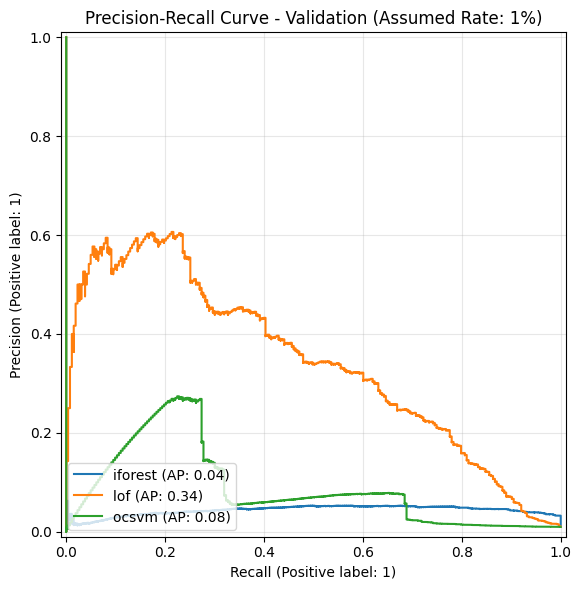

Saved PR curve figure to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/figures/03_pr_curve_validation_1pct.png


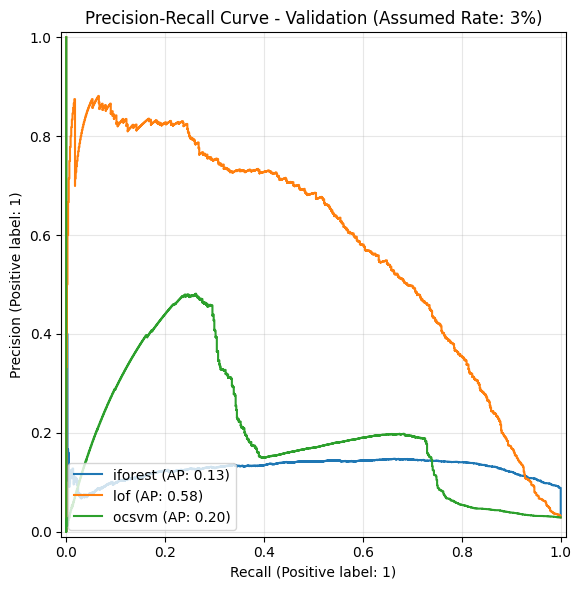

Saved PR curve figure to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/figures/03_pr_curve_validation_3pct.png


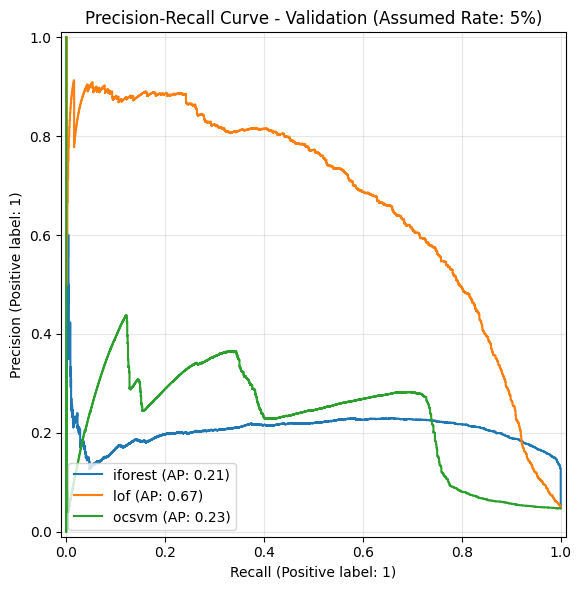

Saved PR curve figure to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/figures/03_pr_curve_validation_5pct.png


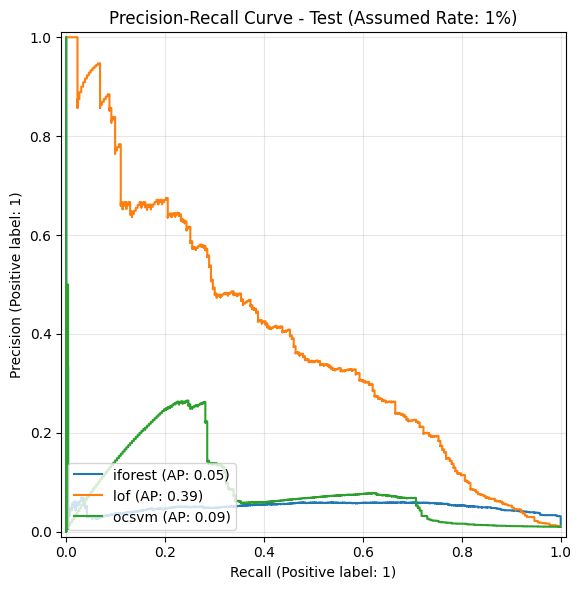

Saved PR curve figure to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/figures/03_pr_curve_test_1pct.png


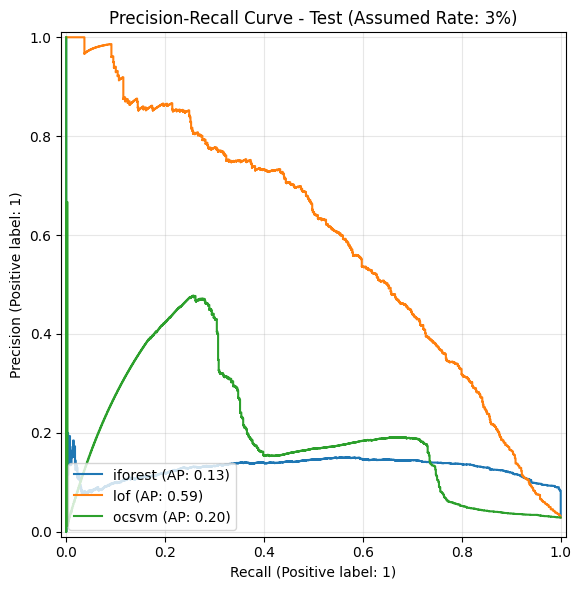

Saved PR curve figure to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/figures/03_pr_curve_test_3pct.png


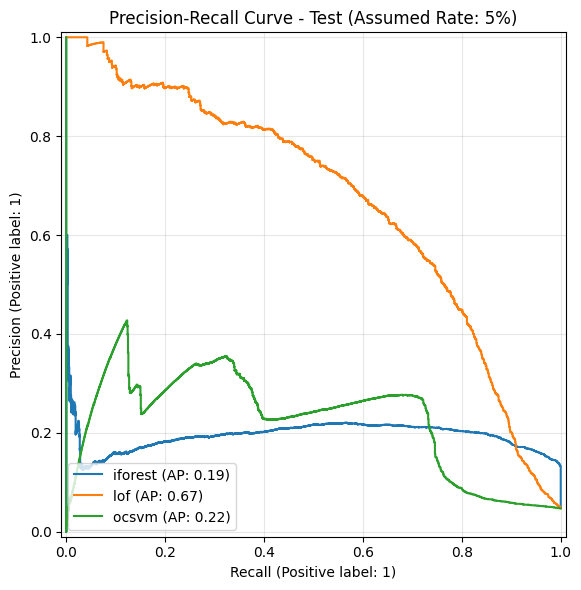

Saved PR curve figure to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/figures/03_pr_curve_test_5pct.png


In [ ]:
plot_metric_pr_curve = 'average_precision'
plot_splits = ['validation', 'test']
RATES_TO_PLOT = sorted(scores_df['assumed_rate'].unique())

for split_name in plot_splits:
    for rate in RATES_TO_PLOT:
        fig, ax = plt.subplots(figsize=(8, 6))
        split_rate_df = scores_df[(scores_df['split'] == split_name) & (scores_df['assumed_rate'] == rate)]

        # Ensure consistent models order for plotting
        models_to_plot = sorted(split_rate_df['model'].unique())

        for model_name in models_to_plot:
            model_data = split_rate_df[split_rate_df['model'] == model_name]
            y_true = model_data['is_injected_anomaly']
            y_scores = model_data['anomaly_score']

            if len(y_true.unique()) > 1: # Check if there are both positive and negative samples
                display = PrecisionRecallDisplay.from_predictions(y_true, y_scores, name=model_name, ax=ax)
                # Add average precision score to the label for clarity
                ap_score = average_precision_score(y_true, y_scores)
                display.ax_.lines[-1].set_label(f'{model_name} (AP: {ap_score:.2f})')
            else:
                print(f'Skipping PR curve for {model_name} in {split_name} at rate {rate}: only one class present.')

        ax.set_title(f'Precision-Recall Curve - {split_name.title()} (Assumed Rate: {rate:.0%})')
        ax.legend(loc='lower left')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()

        # Save the figure
        fig_pr_curve_path = FIGURES_DIR / f'03_pr_curve_{split_name}_{int(rate*100)}pct.png'
        plt.savefig(fig_pr_curve_path, dpi=200, bbox_inches='tight')
        plt.show()
        print(f'Saved PR curve figure to: {fig_pr_curve_path}')